In [ ]:
import json 
import pandas as pd

df = pd.DataFrame(json.load(open("traindata.json", "r")))
df['profit'] = df['profit']>-0.3

In [26]:
df.columns

Index(['rsi1', 'rsi2', 'slpct', 'profit', 'currdaychange', 'atr'], dtype='object')

In [22]:
# ====================
# 1) Imports & Load
# ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, precision_recall_curve, roc_curve,
    brier_score_loss
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

# --- Load your data (update the filename/path) ---
# df = pd.read_csv("your_dataset.csv")
# For now, if you pasted into a notebook, ensure you loaded df.

# Basic hygiene
assert set(['rsi1','rsi2','slpct','profit','currdaychange','atr']).issubset(df.columns), "Missing expected columns."
df = df.copy()
df['profit'] = df['profit'].astype(bool)

# If you have a timestamp column (e.g., 'date'), sort by it:
# df['date'] = pd.to_datetime(df['date'])
# df = df.sort_values('date').reset_index(drop=True)

# Otherwise, assume current row order is chronological
df = df.reset_index(drop=True)


Shape: (1130, 6)

Dtypes:
 rsi1             float64
rsi2             float64
slpct            float64
profit              bool
currdaychange    float64
atr              float64
dtype: object

Target balance (mean of True): 0.2885

Numeric summary:
                 count       mean        std        min        25%        50%  \
rsi1           1130.0  47.152315  13.988121   1.737035  39.095810  48.568343   
rsi2           1130.0  36.233019  22.405774   0.000000  16.728858  38.162081   
slpct          1130.0   0.834779   0.378540   0.500000   0.512956   0.735456   
currdaychange  1130.0   2.367959   5.164354 -23.119165  -0.043844   2.431431   
atr            1130.0   0.435026   0.284414   0.148048   0.294520   0.371857   

                     75%         max  
rsi1           56.449729   89.492051  
rsi2           52.830143  100.000000  
slpct           1.001146    3.707257  
currdaychange   4.691708   27.333519  
atr             0.472795    4.131870  


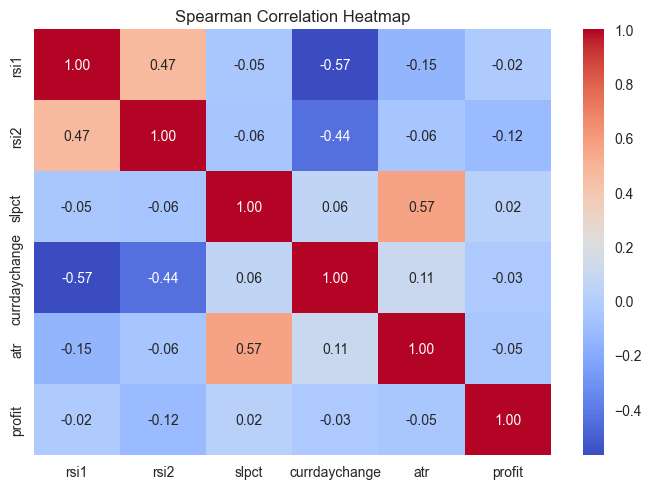

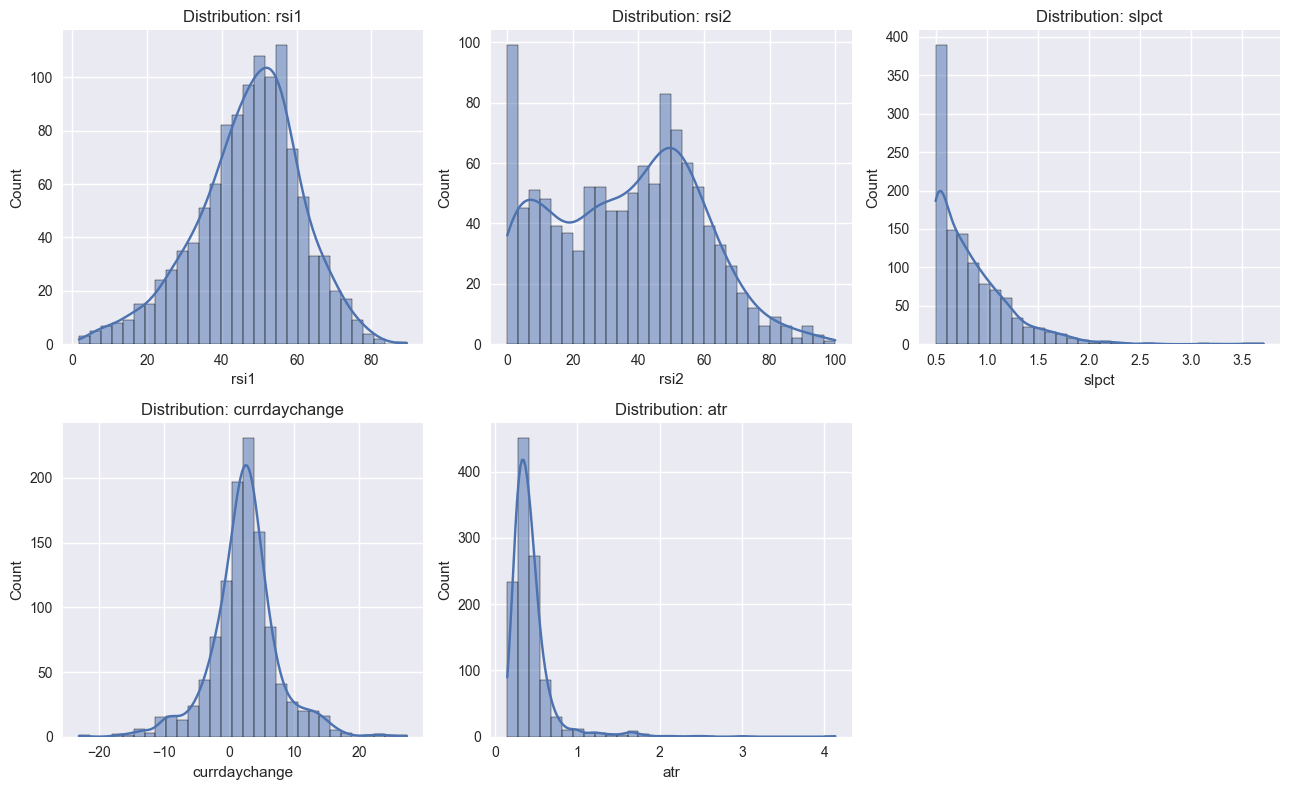

C:\Users\SachinSachan\AppData\Local\Temp\ipykernel_40896\616432952.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(binned)[target].mean()


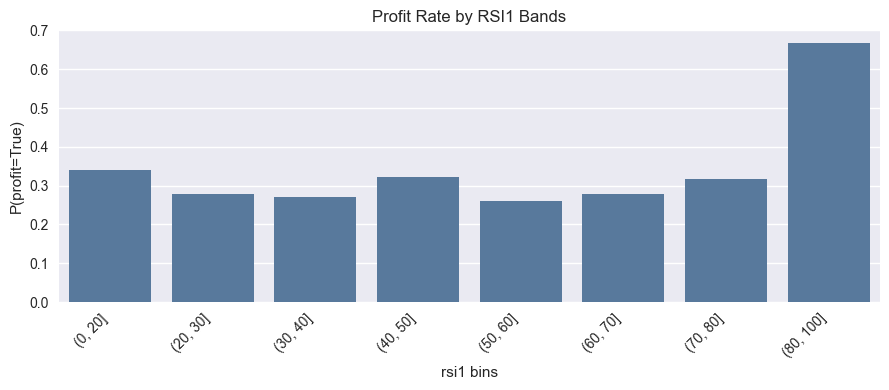

C:\Users\SachinSachan\AppData\Local\Temp\ipykernel_40896\616432952.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(binned)[target].mean()


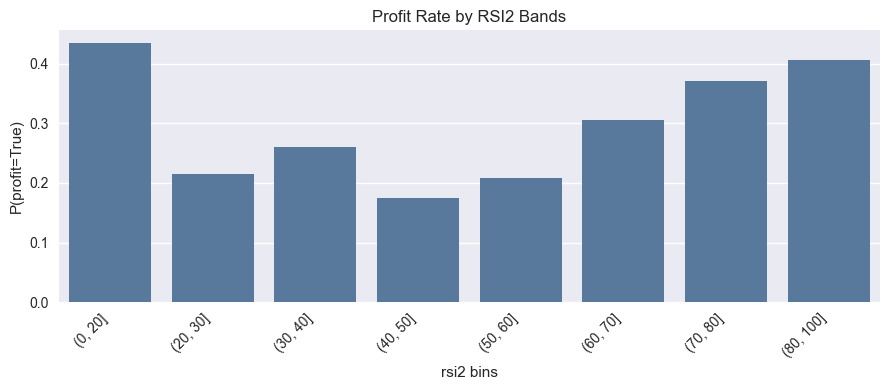

In [23]:
# ====================
# 2) EDA (quick)
# ====================
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nTarget balance (mean of True):", df['profit'].mean().round(4))

print("\nNumeric summary:\n", df[['rsi1','rsi2','slpct','currdaychange','atr']].describe().T)

# Spearman (handles monotonic relationships)
corr = df[['rsi1','rsi2','slpct','currdaychange','atr', 'profit']].copy()
corr['profit'] = corr['profit'].astype(int)
corr_mat = corr.corr(method='spearman')
plt.figure(figsize=(7,5))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation Heatmap")
plt.tight_layout()
plt.show()

# Distributions
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.ravel()
for ax, col in zip(axes, ['rsi1','rsi2','slpct','currdaychange','atr']):
    sns.histplot(df[col], kde=True, ax=ax, bins=30)
    ax.set_title(f"Distribution: {col}")
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

# Lift by RSI bands (does profit rate vary by RSI?)
def plot_lift_by_bins(series, target, bins, title):
    binned = pd.cut(series, bins=bins)
    g = df.groupby(binned)[target].mean()
    g.index = g.index.astype(str)
    plt.figure(figsize=(9,4))
    sns.barplot(x=g.index, y=g.values, color="#4c78a8")
    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.ylabel("P(profit=True)")
    plt.xlabel(series.name + " bins")
    plt.tight_layout()
    plt.show()

plot_lift_by_bins(df['rsi1'], 'profit', bins=[0,20,30,40,50,60,70,80,100], title="Profit Rate by RSI1 Bands")
plot_lift_by_bins(df['rsi2'], 'profit', bins=[0,20,30,40,50,60,70,80,100], title="Profit Rate by RSI2 Bands")

CV Train Accuracy: 0.8912 ± 0.0259
CV Test  Accuracy: 0.6815 ± 0.0173
Best params (full-data refit): {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 5}


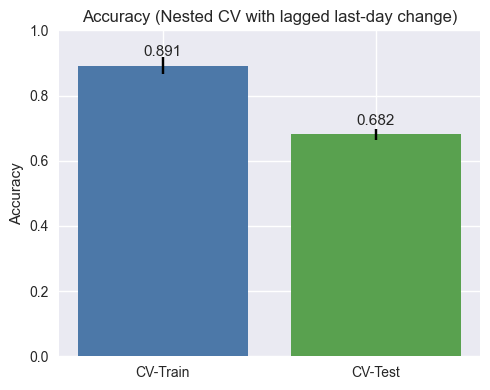

In [27]:
# ==========================================================
# Random trades, include LAST-DAY change as a valid feature:
# - prev_change = lagged currdaychange (per-symbol if symbol exists)
# - Handles imbalance via class_weight
# - Regularized RandomForest
# - StratifiedKFold or GroupKFold (if symbol available)
# - OUTPUT: prints & plots ONLY accuracy (mean ± std)
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold, GroupKFold, GridSearchCV, cross_validate
)

# ---------- 0) Hygiene ----------
required = {'rsi1','rsi2','slpct','profit','currdaychange','atr'}
assert required.issubset(df.columns), f"Missing columns: {required - set(df.columns)}"

df = df.copy()
df['profit'] = df['profit'].astype(int)

has_symbol = 'symbol' in df.columns

# ---------- 1) Create SAFE lag feature(s) from currdaychange ----------
def add_prev_change(g):
    # shift(1) to ensure we only use prior bar/day change
    g['prev_change'] = g['currdaychange'].shift(1)
    # simple volatility normalization (optional but helpful)
    g['atr_roll_50'] = g['atr'].rolling(50, min_periods=10).mean()
    g['prev_change_norm'] = g['prev_change'] / (g['atr_roll_50'] + 1e-6)
    return g

if has_symbol:
    df = df.groupby('symbol', group_keys=False).apply(add_prev_change)
else:
    df = add_prev_change(df)

# Drop rows where lagged features are not available
df = df.dropna(subset=['prev_change', 'prev_change_norm']).reset_index(drop=True)

# ---------- 2) Feature set ----------
# Use features recorded at decision time + safe lagged previous change
features = [
    'rsi1', 'rsi2', 'slpct', 'atr',
    'prev_change', 'prev_change_norm'
]
X = df[features].values
y = df['profit'].values
groups = df['symbol'].values if has_symbol else None

# ---------- 3) CV setup ----------
RANDOM_STATE = 42
n_splits_outer = 5
n_splits_inner = 3

if has_symbol:
    outer_cv = GroupKFold(n_splits=n_splits_outer)
    inner_cv = GroupKFold(n_splits=n_splits_inner)
else:
    outer_cv = StratifiedKFold(n_splits=n_splits_outer, shuffle=True, random_state=RANDOM_STATE)
    inner_cv = StratifiedKFold(n_splits=n_splits_inner, shuffle=True, random_state=RANDOM_STATE)

# ---------- 4) Model + small regularization grid ----------
base_rf = RandomForestClassifier(
    n_estimators=400,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

param_grid = {
    'max_depth': [8, 12],
    'min_samples_leaf': [5, 8],
    'max_features': ['sqrt', 0.5]
}

tuner = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=inner_cv,
    n_jobs=-1,
    refit=True
)

# ---------- 5) Nested CV evaluation (accuracy only) ----------
if has_symbol:
    cv_results = cross_validate(
        tuner, X, y,
        cv=outer_cv,
        groups=groups,
        scoring='accuracy',
        return_train_score=True,
        n_jobs=-1
    )
else:
    cv_results = cross_validate(
        tuner, X, y,
        cv=outer_cv,
        scoring='accuracy',
        return_train_score=True,
        n_jobs=-1
    )

train_acc_mean = float(np.mean(cv_results['train_score']))
train_acc_std  = float(np.std(cv_results['train_score']))
test_acc_mean  = float(np.mean(cv_results['test_score']))
test_acc_std   = float(np.std(cv_results['test_score']))

print(f"CV Train Accuracy: {train_acc_mean:.4f} ± {train_acc_std:.4f}")
print(f"CV Test  Accuracy: {test_acc_mean:.4f} ± {test_acc_std:.4f}")

# ---------- 6) Refit best model on all data (optional) ----------
final_tuner = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=inner_cv,
    n_jobs=-1,
    refit=True
)
if has_symbol:
    final_tuner.fit(X, y, groups=groups)
else:
    final_tuner.fit(X, y)

best_model = final_tuner.best_estimator_
print("Best params (full-data refit):", final_tuner.best_params_)

# ---------- 7) Plot ONLY accuracy (mean ± std) ----------
plt.figure(figsize=(5,4))
plt.bar(["CV-Train", "CV-Test"], [train_acc_mean, test_acc_mean],
        yerr=[train_acc_std, test_acc_std], capsize=6,
        color=["#4c78a8", "#59a14f"])
plt.ylim(0, 1)
for i, v in enumerate([train_acc_mean, test_acc_mean]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center", va="bottom", fontsize=11)
plt.title("Accuracy (Nested CV with lagged last-day change)")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()